![image.png](https://i.imgur.com/a3uAqnb.png)

# Image Generation Using Denoising Diffusion Models

This notebook has been partly adapted from the excellent diffusion model [tutorial](https://huggingface.co/blog/annotated-diffusion) by Rogge & Rasul and follows the original [DDPM paper](https://arxiv.org/abs/2006.11239) by Ho et al.

### **📌 The Core Idea of Diffusion Models**
While GANs can produce high-quality results, they are notorious for unstable training. Diffusion models offer a more stable alternative. They work by reversing a gradual noising process.

1.  **Forward (Diffusion) Process**: We start with a real image and slowly add Gaussian noise over a series of timesteps (`T`). This is a fixed, non-trainable process that eventually turns the image into pure noise.

2.  **Reverse (Denoising) Process**: We train a neural network (typically a U-Net) to reverse this process. Starting from random noise, the model learns to gradually remove the noise at each timestep, ultimately generating a clean, realistic image.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import Compose, ToTensor, Lambda, Resize, CenterCrop, Normalize
from torchsummary import summary
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from tqdm import tqdm
import numpy as np
from PIL import Image
import os
import kagglehub
import matplotlib.animation as animation
from matplotlib import rc

### **🔹 Model Configuration**
Here we define the key hyperparameters for our model and training process.

In [19]:
EPOCHS = 25
LEARNING_RATE = 2e-3
BATCH_SIZE = 128
TIME_EMBEDDING_DIM = 200
TIMESTAMPS = 400
IMAGE_SIZE = 64  # Anime faces will be resized to 64x64

## 1️⃣ The Dataset: Anime Faces
- **Images**: Anime-style portrait images **(64x64, RGB)**
- **Shape**: `(batch_size, 3, 64, 64)`
- **Normalization**: Images are transformed from `[0, 255]` to `[0, 1]` (via `ToTensor`) and then to `[-1, 1]`. This normalization helps stabilize training.

In [3]:
transform_steps = Compose([
    Resize(IMAGE_SIZE),          # Resize to a consistent 64x64
    CenterCrop(IMAGE_SIZE),      # Crop to the center to ensure dimensions
    ToTensor(),                  # Convert image to a PyTorch tensor (scales to [0, 1])
    Lambda(lambda t: (t * 2) - 1)  # Normalize to the range [-1, 1]
])

In [4]:
# Download the dataset from Kaggle
path = kagglehub.dataset_download("soumikrakshit/anime-faces")
print("Path to dataset files:", path)

# The dataset path will be the downloaded path
dataset_path = os.path.join(path,'data')

Using Colab cache for faster access to the 'anime-faces' dataset.
Path to dataset files: /kaggle/input/anime-faces


### **🔹 Custom Dataset Class**
We create a custom `Dataset` to load the image files from the directory and apply the defined transformations.

In [16]:
class AnimeFacesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, 0  # Return 0 as dummy label since we don't need labels

# Create dataset and dataloader
anime_dataset = AnimeFacesDataset(root_dir=dataset_path, transform=transform_steps)
train_dataloader = DataLoader(anime_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(anime_dataset.__len__())

21551


### **🔹 Displaying Sample Images**
Let's visualize a few images from our dataset to see what we're working with.

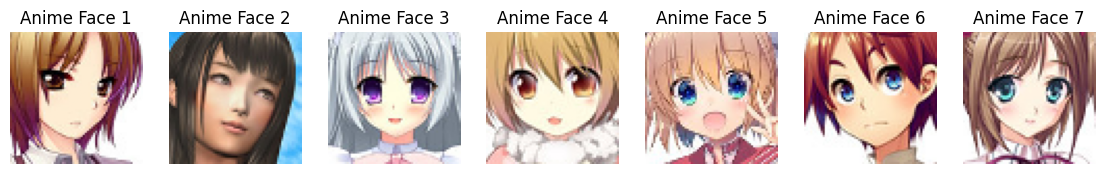

In [6]:
figure = plt.figure(figsize=(14, 14))
cols, rows = 7, 1
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(anime_dataset), size=(1,)).item()
    img, _ = anime_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(f"Anime Face {i}")
    plt.axis("off")
    # Convert from [-1,1] back to [0,1] for display and clamp to valid range
    img_display = np.clip((img.numpy() + 1) / 2, 0, 1)
    plt.imshow(img_display.transpose(1, 2, 0))
plt.show()

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2️⃣ The Theory: How Diffusion Models Work

### **🔹 The Forward Diffusion Process (q)**

The forward process, denoted as `q`, is a fixed Markov chain that gradually adds Gaussian noise to an image $\mathbf{x}_0$ over `T` timesteps. The amount of noise added at each step `t` is controlled by a **variance schedule** $\{\beta_t\}_{t=1}^T$.

$$
q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t \mathbf{I})
$$

A key feature, which the authors call the **"nice property"**, allows us to sample a noisy image $\mathbf{x}_t$ directly from the original image $\mathbf{x}_0$ at any timestep `t`, without iterating through all the intermediate steps. This makes training very efficient.

Let $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$. Then:

$$
q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, (1 - \bar{\alpha}_t)\mathbf{I})
$$

This means we can get $\mathbf{x}_t$ by taking the original image $\mathbf{x}_0$, scaling it by $\sqrt{\bar{\alpha}_t}$, and adding scaled noise $\epsilon \sim \mathcal{N}(0, I)$:

$$
\mathbf{x}_t = \sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \, \mathbf{\epsilon}
$$




## 3️⃣ The Model: A U-Net for Noise Prediction

The model architecture needs to take a noisy image and a timestep as input and output a tensor of the same shape as the image (the predicted noise). A **U-Net** is perfectly suited for this task.

### **🔹 Key Architectural Components**
1.  **Downsampling Path**: A series of convolutional layers that reduce the spatial dimensions of the image, capturing contextual information.
2.  **Bottleneck**: A set of linear layers that process the flattened feature map.
3.  **Upsampling Path**: A series of transposed convolutional layers that increase the spatial dimensions back to the original image size.
4.  **Skip Connections**: Connections that link layers from the downsampling path to corresponding layers in the upsampling path. This is crucial for preserving high-frequency details and helps the model reconstruct the image accurately.
5.  **Time Embeddings**: Since the model needs to know *which* noise level `t` it's dealing with, we convert the scalar timestep `t` into a vector using **Sinusoidal Position Embeddings**. This vector is then incorporated into each block of the U-Net.

### **🔹 Helper Blocks for the U-Net**
First, we define the building blocks of our U-Net: convolutional blocks, upsampling blocks, and the time embedding module.

In [8]:
class ConvBlock(nn.Module):
  """Convolution Block with time embedding integration."""
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding, time_emb_dim, last=False):
    super(ConvBlock, self).__init__()
    self.last = last
    self.time_mlp = nn.Linear(time_emb_dim, in_channels)
    self.conv_layer = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
    if not self.last:
      self.batch_norm_layer = nn.BatchNorm2d(out_channels)
      self.act = nn.LeakyReLU()

  def forward(self, x, t):
    t_emb = self.time_mlp(t)
    # Add time embedding to the input feature map
    x = x + t_emb.view(*t_emb.shape, 1, 1)
    x = self.conv_layer(x)
    if not self.last:
      x = self.batch_norm_layer(x)
      x = self.act(x)
    return x

class UpSampleBlock(nn.Module):
  """Up Sampling Block with time embedding integration."""
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding, output_padding, time_emb_dim, last=False):
    super(UpSampleBlock, self).__init__()
    self.last = last
    self.time_mlp = nn.Linear(time_emb_dim, in_channels)
    self.conv_trans_layer = nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding, output_padding=output_padding)
    if not self.last:
      self.batch_norm_layer = nn.BatchNorm2d(out_channels)
      self.act = nn.LeakyReLU()

  def forward(self, x, t):
    t_emb = self.time_mlp(t)
    # Add time embedding to the input feature map
    x = x + t_emb.view(*t_emb.shape, 1, 1)
    x = self.conv_trans_layer(x)
    if not self.last:
      x = self.batch_norm_layer(x)
      x = self.act(x)
    return x

class LinearBlock(nn.Module):
  """Linear Block for the bottleneck with time embedding integration."""
  def __init__(self, in_dim, out_dim, time_emb_dim):
    super(LinearBlock, self).__init__()
    self.time_mlp = nn.Linear(time_emb_dim, in_dim)
    self.linear_layer = nn.Linear(in_dim, out_dim)
    self.batch_norm_layer = nn.BatchNorm1d(out_dim)
    self.act = nn.LeakyReLU()

  def forward(self, x, t):
    t_emb = self.time_mlp(t)
    # Add time embedding to the flattened features
    x = x + t_emb
    x = self.linear_layer(x)
    x = self.batch_norm_layer(x)
    x = self.act(x)
    return x

class SinusoidalPositionEmbeddings(nn.Module):
    """Encodes timestep `t` into a higher-dimensional vector."""
    def __init__(self, dim):
      super(SinusoidalPositionEmbeddings, self).__init__()
      self.dim = dim

    def forward(self, time):
      device = time.device
      half_dim = self.dim // 2
      embeddings = np.log(10000) / (half_dim - 1)
      embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
      embeddings = time[:, None] * embeddings[None, :]
      embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
      return embeddings

### **🔹 The Full Diffusion Model**
Now we assemble the blocks into the full U-Net architecture.

- **Input**: A batch of noisy images `x` of shape `(batch_size, 3, 64, 64)` and their corresponding timesteps `t` of shape `(batch_size,)`.
- **Output**: A tensor of predicted noise `ε_θ` with the same shape as the input image: `(batch_size, 3, 64, 64)`.

In [9]:
class Reshape(nn.Module):
  """A custom reshape layer."""
  def __init__(self, shape):
    super(Reshape, self).__init__()
    self.shape = shape

  def forward(self, x):
    return x.view(*self.shape)

class DiffusionModel(nn.Module):
    """Diffusion model with a U-Net architecture for RGB images."""
    def __init__(self, time_emb_dim):
        super(DiffusionModel, self).__init__()
        self.time_emb_dim = time_emb_dim

        # First, process the timestep t into a time embedding
        self.time_embedding_model = nn.Sequential(
            SinusoidalPositionEmbeddings(200),
            nn.Linear(200, time_emb_dim),
            nn.LeakyReLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        # === ENCODER (Downsampling Path) ===
        self.dsb_1 = ConvBlock(in_channels=3, out_channels=64, kernel_size=5, stride=2, padding=2, time_emb_dim=time_emb_dim) # 64x64 -> 32x32
        self.conv1 = ConvBlock(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1, time_emb_dim=time_emb_dim)
        self.dsb_2 = ConvBlock(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1, time_emb_dim=time_emb_dim) # 32x32 -> 16x16
        self.conv2 = ConvBlock(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1, time_emb_dim=time_emb_dim)
        self.dsb_3 = ConvBlock(in_channels=256, out_channels=512, kernel_size=3, stride=2, padding=1, time_emb_dim=time_emb_dim) # 16x16 -> 8x8

        self.flatten = nn.Flatten(1,-1)

        # === BOTTLENECK ===
        self.linear_1 = LinearBlock(in_dim=512*8*8, out_dim=512, time_emb_dim=time_emb_dim)
        self.linear_2 = LinearBlock(in_dim=512, out_dim=256, time_emb_dim=time_emb_dim)
        self.linear_3 = LinearBlock(in_dim=256, out_dim=512, time_emb_dim=time_emb_dim)
        self.linear_4 = LinearBlock(in_dim=512, out_dim=512*8*8, time_emb_dim=time_emb_dim)

        self.reshape = Reshape((-1,512,8,8))

        # === DECODER (Upsampling Path) ===
        self.usb_1 = UpSampleBlock(in_channels=512, out_channels=256, kernel_size=3, stride=2, padding=1, output_padding=1, time_emb_dim=time_emb_dim) # 8x8 -> 16x16
        self.conv3 = ConvBlock(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1, time_emb_dim=time_emb_dim)
        self.usb_2 = UpSampleBlock(in_channels=256, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1, time_emb_dim=time_emb_dim) # 16x16 -> 32x32
        self.conv4 = ConvBlock(in_channels=128, out_channels=64, kernel_size=3, stride=1, padding=1, time_emb_dim=time_emb_dim)
        self.usb_3 = UpSampleBlock(in_channels=64, out_channels=32, kernel_size=5, stride=2, padding=2, output_padding=1, time_emb_dim=time_emb_dim) # 32x32 -> 64x64
        self.conv5 = ConvBlock(in_channels=32, out_channels=3, kernel_size=1, stride=1, padding=0, time_emb_dim=time_emb_dim, last=True) # Final output layer

    def forward(self, x, t):
        # 1. Get the time embedding
        t = self.time_embedding_model(t)

        # 2. Pass through the Encoder, saving outputs for skip connections
        x1 = self.dsb_1(x, t)    # (64, 32, 32)
        x2 = self.conv1(x1, t)   # (128, 32, 32)
        x3 = self.dsb_2(x2, t)   # (256, 16, 16)
        x4 = self.conv2(x3, t)   # (256, 16, 16)
        x5 = self.dsb_3(x4, t)   # (512, 8, 8)

        # 3. Pass through the Bottleneck
        x5_ = self.flatten(x5)
        x6 = self.linear_1(x5_, t)
        x7 = self.linear_2(x6, t)
        x = self.linear_3(x7, t)
        x = self.linear_4(x+x6, t) # Skip connection in bottleneck
        x = self.reshape(x)

        # 4. Pass through the Decoder, using skip connections
        x = self.usb_1(x+x5, t)  # Skip connection from x5
        x = self.conv3(x+x4, t)  # Skip connection from x4
        x = self.usb_2(x+x3, t)  # Skip connection from x3
        x = self.conv4(x+x2, t)  # Skip connection from x2
        x = self.usb_3(x+x1, t)  # Skip connection from x1
        x = self.conv5(x, t)     # Final output

        return x


In [10]:
model = DiffusionModel(time_emb_dim=TIME_EMBEDDING_DIM)
model.to(device)

DiffusionModel(
  (time_embedding_model): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=200, out_features=200, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=200, out_features=200, bias=True)
  )
  (dsb_1): ConvBlock(
    (time_mlp): Linear(in_features=200, out_features=3, bias=True)
    (conv_layer): Conv2d(3, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (batch_norm_layer): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): LeakyReLU(negative_slope=0.01)
  )
  (conv1): ConvBlock(
    (time_mlp): Linear(in_features=200, out_features=64, bias=True)
    (conv_layer): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batch_norm_layer): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): LeakyReLU(negative_slope=0.01)
  )
  (dsb_2): ConvBlock(
    (time_mlp): Linear(in_features=200, out_features=128, bias=True)


## 4️⃣ The Diffusion Process & Loss Function

### **🔹 Pre-calculating The Diffusion Schedule**

We need to define the variance schedule $\{\beta_t\}_{t=1}^T$. A simple linear schedule works well. From $\beta_t$, we can pre-calculate all the $\alpha_t$ and $\bar{\alpha}_t$ values needed for the forward process (`q_sample`) and the reverse sampling process.


In [11]:
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

# define beta schedule
betas = linear_beta_schedule(timesteps=TIMESTAMPS)

# define alphas
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = nn.functional.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# calculations for diffusion q(x_t | x_{t-1}) and others
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# calculations for posterior q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def extract(a, t, x_shape):
    """Helper function to extract the correct alpha/beta values for a batch of timesteps."""
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)


### **🔹 The Forward Pass (`q_sample`)**

This function implements the "nice property" described earlier. It takes an original image `x_start` and a timestep `t` and returns a noisy version of the image at that timestep, $\mathbf{x}_t = \sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \, \mathbf{\epsilon}$



In [12]:
# forward diffusion (using the nice property)
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x_start.shape
    )

    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

### **🔹 The Loss Function (`p_losses`)**
This function defines our training objective. For a given batch of images:
1.  A random noise tensor `noise` is created.
2.  A noisy version of the image, `x_noisy`, is created using `q_sample`.
3.  The model predicts the noise, `predicted_noise`, from `x_noisy`.
4.  The loss is the `smooth_l1_loss` (a robust version of MSE) between the `noise` and `predicted_noise`.

In [13]:
def p_losses(denoise_model, x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    predicted_noise = denoise_model(x_noisy, t)

    loss = nn.functional.smooth_l1_loss(noise, predicted_noise)

    return loss

## 5️⃣ Training the Model
Now we're ready to train. The training loop performs the following steps for each batch:

1.  Load a batch of real images.
2.  For each image, sample a random timestep `t` from `0` to `T-1`.
3.  Calculate the loss using our `p_losses` function.
4.  Perform backpropagation to compute gradients.
5.  Update the model's weights using the optimizer.

In [20]:
# Defining the optimizer here
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Lists to store loss history for plotting
train_losses = []
epoch_losses = []

In [21]:
for i in range(1, EPOCHS+1):
    running_loss = 0
    epoch_loss = 0
    batch_count = 0

    pbar = tqdm(train_dataloader)
    for b, data in enumerate(pbar):
        # Every data instance is an input + label pair. We don't need the label
        inputs, _ = data
        inputs = inputs.to(device)

        # Zero the gradients for every batch!
        optimizer.zero_grad()

        # Sample a random timestep for each image in the batch
        t = torch.randint(0, TIMESTAMPS, (inputs.shape[0],), device=device).long()

        # Compute the loss and its gradients
        loss = p_losses(model, inputs, t)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Track losses
        batch_loss = loss.item()
        train_losses.append(batch_loss)
        epoch_loss += batch_loss
        batch_count += 1

        # Update Progress Bar
        pbar.set_description(f"Epoch {i}/{EPOCHS}")
        pbar.set_postfix({"batch_loss": batch_loss, "avg_epoch_loss": epoch_loss/batch_count})

    # Store average epoch loss for overall trend analysis
    avg_epoch_loss = epoch_loss / batch_count
    epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {i} - Average Loss: {avg_epoch_loss:.6f}")

Epoch 1/25: 100%|██████████| 169/169 [02:18<00:00,  1.22it/s, batch_loss=0.121, avg_epoch_loss=0.0943]


Epoch 1 - Average Loss: 0.094262


Epoch 2/25: 100%|██████████| 169/169 [01:01<00:00,  2.76it/s, batch_loss=0.0696, avg_epoch_loss=0.0745]


Epoch 2 - Average Loss: 0.074462


Epoch 3/25: 100%|██████████| 169/169 [01:02<00:00,  2.72it/s, batch_loss=0.0623, avg_epoch_loss=0.0685]


...

Epoch 23 - Average Loss: 0.049467


Epoch 24/25: 100%|██████████| 169/169 [01:05<00:00,  2.58it/s, batch_loss=0.0448, avg_epoch_loss=0.0485]


Epoch 24 - Average Loss: 0.048526


Epoch 25/25: 100%|██████████| 169/169 [01:07<00:00,  2.52it/s, batch_loss=0.0476, avg_epoch_loss=0.0482]

Epoch 25 - Average Loss: 0.048174


### **🔹 Plotting the Training Progress**

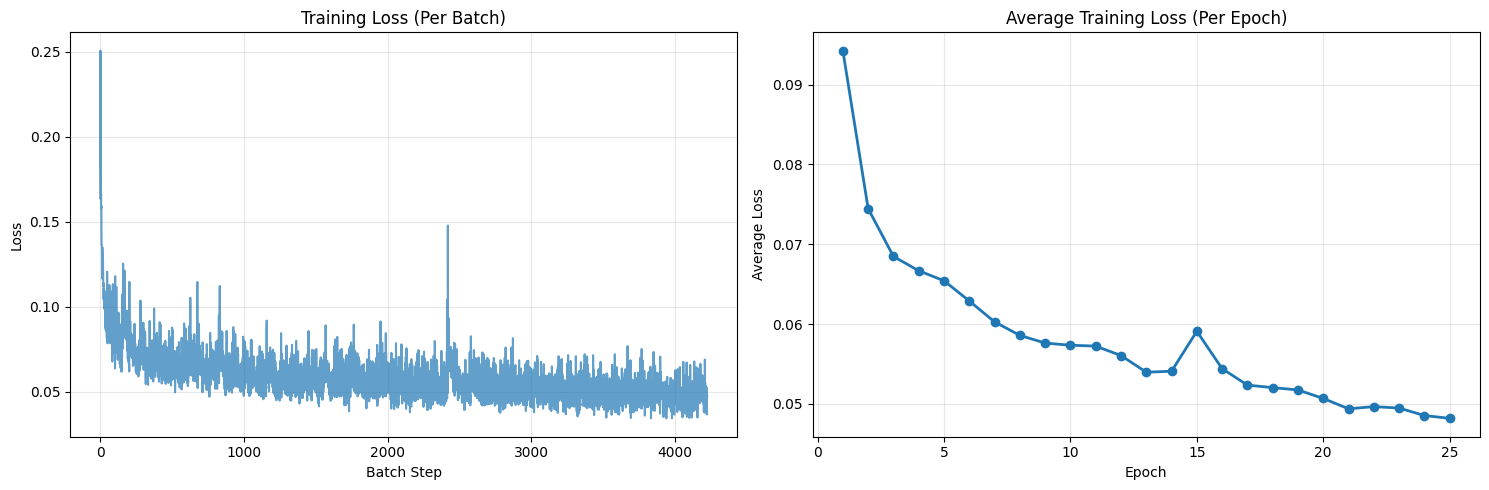

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot batch-wise losses
ax1.plot(train_losses, alpha=0.7)
ax1.set_title('Training Loss (Per Batch)')
ax1.set_xlabel('Batch Step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

# Plot epoch-wise average losses
ax2.plot(range(1, len(epoch_losses) + 1), epoch_losses, 'o-', linewidth=2, markersize=6)
ax2.set_title('Average Training Loss (Per Epoch)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Average Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6️⃣ Generating New Images (The Reverse Process)

Generating new images involves running the reverse process. We start with pure Gaussian noise (at timestep `T`) and iteratively apply our trained model to denoise it, one step at a time, until we reach timestep `0`.

The sampling process is summarized in the paper as Algorithm 2:

<img src="https://i.imgur.com/tTGrKg8.png" width="500" />

At each step `t`, the model predicts the noise $\mathbf{\epsilon}_\theta(\mathbf{x}_t, t)$. We use this prediction to calculate the mean of the denoised image $\mathbf{x}_{t-1}$. Then, we add a small amount of variance (noise) back in, which is crucial for generating diverse samples.


In [23]:
@torch.no_grad()
def p_sample(model, x, t, t_index):
    """Performs one step of the reverse (sampling) process."""
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # Equation 11 in the paper
    # Use our model (noise predictor) to predict the mean of the previous image
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean
    else:
        # Add noise to introduce variance in the generation
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        # Algorithm 2 line 4:
        return model_mean + torch.sqrt(posterior_variance_t) * noise

# Algorithm 2 (the full sampling loop)
@torch.no_grad()
def p_sample_loop(model, shape):
    device = next(model.parameters()).device
    b = shape[0]

    # Start from pure noise (for each example in the batch)
    img = torch.randn(shape, device=device)
    imgs = []

    # Iterate backwards from T-1 to 0
    for i in tqdm(reversed(range(0, TIMESTAMPS)), desc='Sampling Loop', total=TIMESTAMPS):
        img = p_sample(model, img, torch.full((b,), i, device=device, dtype=torch.long), i)
        imgs.append(img.cpu().numpy())
    return imgs

@torch.no_grad()
def sample(model, image_size, batch_size=16, channels=3):
    return p_sample_loop(model, shape=(batch_size, channels, image_size, image_size))

### **🔹 Generating a Batch of Images**
Let's use our trained model to generate a grid of new anime faces.

Sampling Loop: 100%|██████████| 400/400 [00:04<00:00, 90.70it/s]


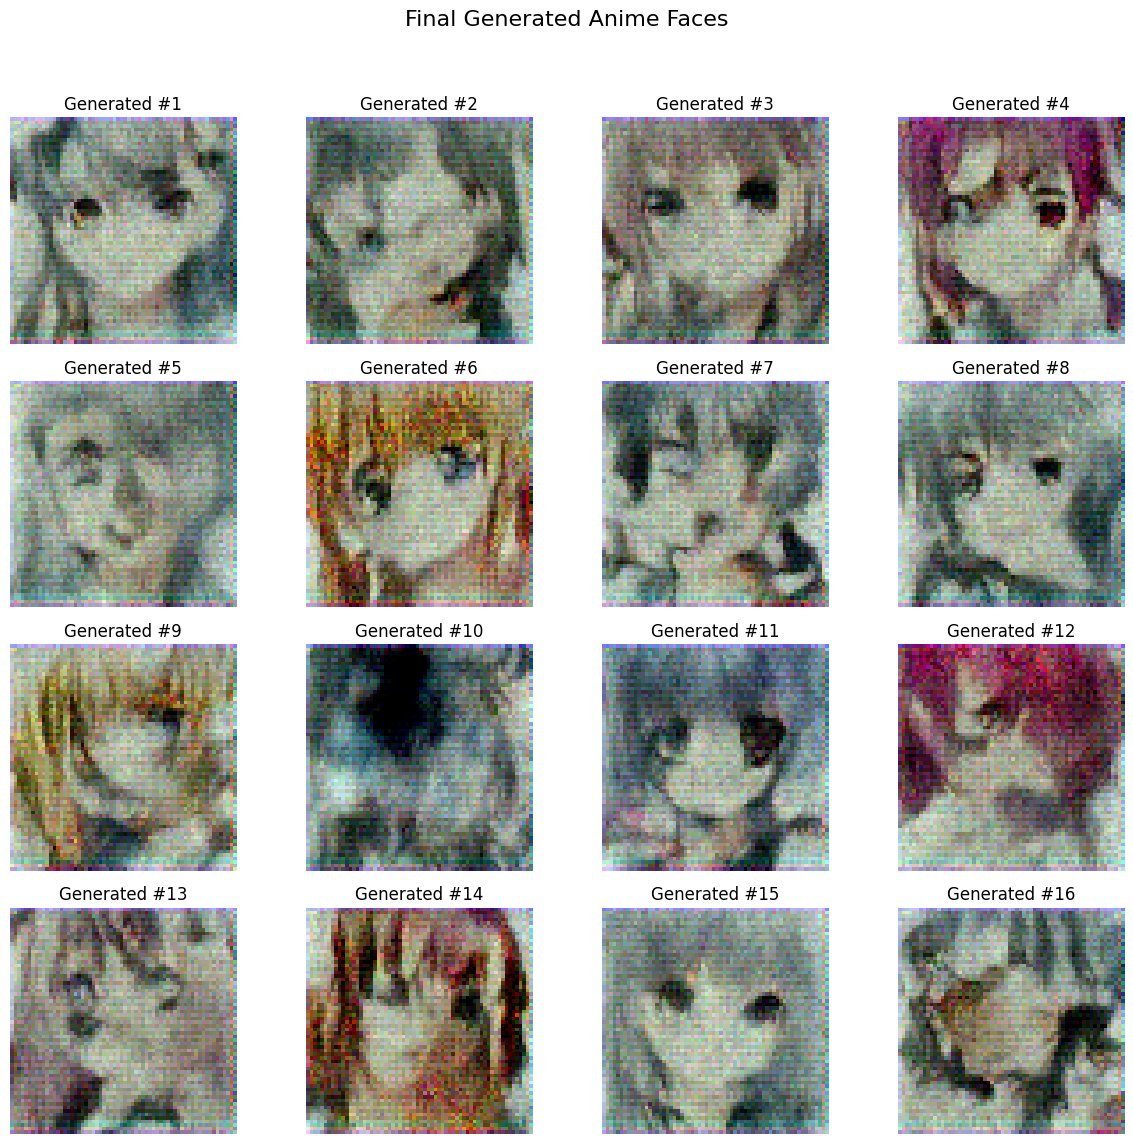

In [24]:
numberToGenerate = 16

# Sample 16 images
samples = sample(model, image_size=IMAGE_SIZE, batch_size=numberToGenerate, channels=3)

# The final generated images are at the last step of the sampling process
final_samples = samples[-1]

# Show all generated samples
figure = plt.figure(figsize=(12, 12))
cols, rows = 4, 4

for i in range(numberToGenerate):
    sample_img = final_samples[i]
    # Convert from [-1,1] to [0,1] and clamp to valid range
    sample_img = np.clip((sample_img + 1) / 2, 0, 1)

    figure.add_subplot(rows, cols, i + 1)
    plt.imshow(sample_img.transpose(1, 2, 0))
    plt.title(f"Generated #{i+1}")
    plt.axis('off')

plt.suptitle("Final Generated Anime Faces", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **🔹 Visualizing the Denoising Process**
We can create an animation to see how a single image evolves from pure noise to a recognizable face over the `T` sampling steps.

In [25]:
# Choose one of the generated samples to animate
random_index = 10

fig = plt.figure(figsize=(8, 8))
plt.axis("off")
ims = []
for i in range(TIMESTAMPS):
    # Get the image at step i for the chosen random_index
    sample_img = samples[i][random_index]
    # Convert from [-1,1] to [0,1] and clamp to valid range
    sample_img = np.clip((sample_img + 1) / 2, 0, 1)
    im = plt.imshow(sample_img.transpose(1, 2, 0), animated=True)
    ims.append([im])

animate = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)
rc('animation', html='jshtml')
animate

Output hidden; open in https://colab.research.google.com to view.

## 7️⃣ Conclusion & Next Steps

We have successfully built and trained a Denoising Diffusion Probabilistic Model (DDPM) to generate anime faces. We've seen how the model learns to reverse a fixed noising process to create new images from scratch.

### **📝 Exercises for Further Exploration**
1.  **Training Duration**: Train for more `EPOCHS`. Diffusion models benefit greatly from longer training. How do the results change after 200 or 500 epochs?
2.  **Timesteps**: Experiment with different `TIMESTAMPS` values (e.g., 200, 500, 1000). A larger `T` means a more gradual (and potentially more accurate) denoising process, but also slower sampling.
3.  **Beta Schedule**: The `linear_beta_schedule` is just one option. Research and implement other schedules, like a `cosine` schedule, which is often used in modern papers. How does it affect the final image quality?
4.  **Model Architecture**: Modify the U-Net. Try adding more ResNet-style blocks, using different attention mechanisms, or changing the number of channels (`64`, `128`, etc.) in the convolutional layers.
5.  **Dataset**: Try training this model on a different dataset, like CIFAR-10 or Fashion-MNIST. You will likely need to adjust the model architecture (e.g., `IMAGE_SIZE`, input channels) accordingly.

### Contributed by: Ali Habibullah.
